# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [2]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

?>4A8AB5<0  W i n d o w s   4;O  L i n u x   =5  8<55B  CAB0=>2;5==KE  48AB@81CB82>2. 
 
 'B>1K  CAB@0=8BL  MBC  ?@>1;5<C,   CAB0=>28B5  48AB@81CB82  A  8=AB@C:F8O<8  =865: 
 
 
 
 A?>;L7C9B5  " w s l . e x e   - - l i s t   - - o n l i n e '   4;O  ?5@5G8A;5=8O  4>ABC?=KE  48AB@81CB82>2
 
 8  " w s l . e x e   - - i n s t a l l   < D i s t r o > "   4;O  CAB0=>2:8. 
 
 


In [3]:
# Install gymnasium if you didn't
!pip install "gymnasium[toy_text,classic_control]"

C:\Users\titanpc\anaconda3\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


state vector dim = 4
n_actions = 2


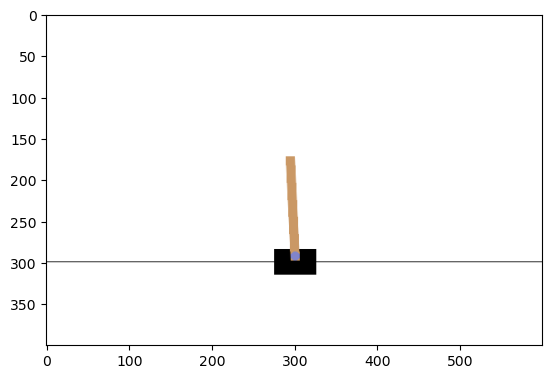

In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [6]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))

MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 20))

In [7]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):


        probs = agent.predict_proba([s])[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        a = np.random.choice(env.action_space.n, p=probs)

        new_s, r, terminated, truncated, _ = env.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
            
    return states, actions, total_reward

In [8]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[-0.00960088 -0.04465943 -0.03137192 -0.00920492]
 [-0.01049406 -0.23931774 -0.03155602  0.27341706]
 [-0.01528042 -0.04376008 -0.02608768 -0.02904935]
 [-0.01615562 -0.23849839 -0.02666866  0.25528982]
 [-0.02092559 -0.04300603 -0.02156287 -0.04568412]]
actions: [0, 1, 0, 1, 1]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [10]:
import numpy as np

def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []

    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions

# Training loop
Generate sessions, select N best and fit to those.

In [12]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 209.500, threshold=229.000


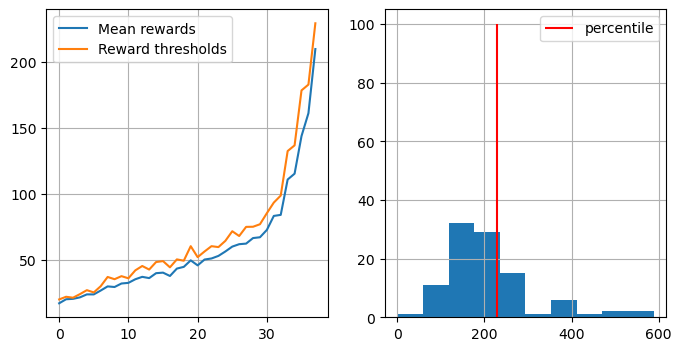

You Win! You may stop training now via KeyboardInterrupt.


In [13]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)
    
    rewards_batch = np.array(rewards_batch)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    if len(elite_states) > 0:
        agent.partial_fit(elite_states, elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")
        break

# Results

In [15]:
from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


C:\Users\titanpc\anaconda3\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
C:\Users\titanpc\anaconda3\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at C:\Users\titanpc\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [16]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1] 

if "google.colab" in sys.modules:
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


Для оценки влияния гиперпараметров percentile и n_sessions на стабильность и скорость сходимости метода кросс-энтропии проводится два изолированных эксперимента.
В первом эксперименте фиксируется n_sessions = 250, а percentile (30, 50, 80). Во втором эксперименте фиксируется percentile = 50, а изменяется n_sessions (100, 250, 500).

--- Влияние percentile  ---
Обучение: n_sessions=250, percentile=30
Обучение: n_sessions=250, percentile=50
Обучение: n_sessions=250, percentile=80

--- Влияние n_sessions ---
Обучение: n_sessions=100, percentile=50
Обучение: n_sessions=250, percentile=50
Обучение: n_sessions=500, percentile=50


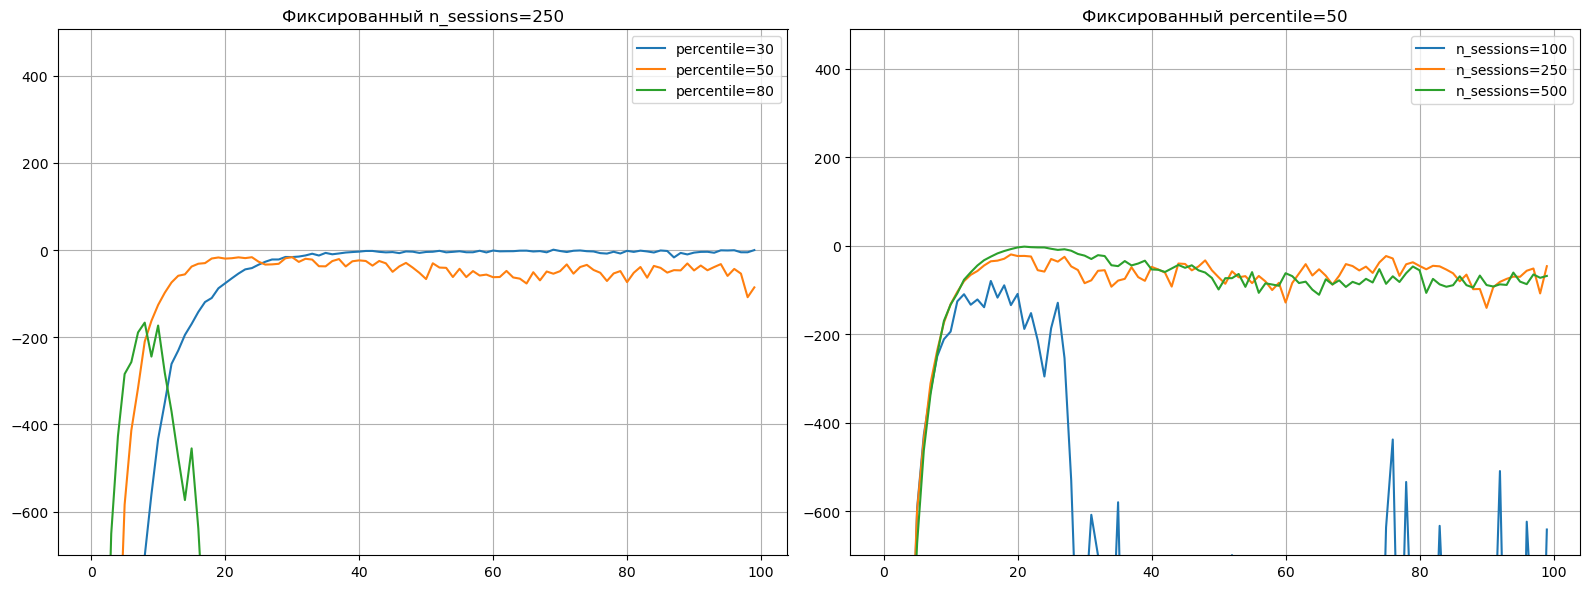

In [19]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env_taxi = gym.make("Taxi-v3").env
n_states = env_taxi.observation_space.n
n_actions = env_taxi.action_space.n

def initialize_policy(n_states, n_actions):
    return np.ones((n_states, n_actions)) / n_actions

def generate_session_tabular(env, policy, t_max=10**4):
    states, actions = [], []
    total_reward = 0.0
    s, _ = env.reset()
    
    for t in range(t_max):
        a = np.random.choice(n_actions, p=policy[s])
        new_s, r, terminated, truncated, _ = env.step(a)
        
        states.append(s)
        actions.append(a)
        total_reward += r
        
        s = new_s
        if terminated or truncated:
            break
            
    return states, actions, total_reward

def select_elites(states_batch, actions_batch, rewards_batch, percentile=100):
    reward_threshold = np.percentile(rewards_batch, percentile)
    
    elite_states = []
    elite_actions = []
    
    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])
            
    return elite_states, elite_actions

def get_new_policy(elite_states, elite_actions):
    new_policy = np.zeros([n_states, n_actions])
    
    for s, a in zip(elite_states, elite_actions):
        new_policy[s, a] += 1
        
    for s in range(n_states):
        row_sum = np.sum(new_policy[s])
        if row_sum > 0:
            new_policy[s] /= row_sum
        else:
            new_policy[s] = np.ones(n_actions) / n_actions
            
    return new_policy

def evaluate_cem(n_sessions, percentile, learning_rate=0.5, n_epochs=100):
    policy = initialize_policy(n_states, n_actions)
    mean_rewards_log = []
    
    for i in range(n_epochs):
        sessions = [generate_session_tabular(env_taxi, policy) for _ in range(n_sessions)]
        states_batch, actions_batch, rewards_batch = zip(*sessions)
        
        elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
        new_policy = get_new_policy(elite_states, elite_actions)
        
        policy = learning_rate * new_policy + (1 - learning_rate) * policy
        mean_rewards_log.append(np.mean(rewards_batch))
        
    return mean_rewards_log

configs_percentile = [
    (250, 30),
    (250, 50),
    (250, 80)
]

configs_sessions = [
    (100, 50),
    (250, 50),
    (500, 50)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

print("--- Влияние percentile  ---")
for n_sess, perc in configs_percentile:
    print(f"Обучение: n_sessions={n_sess}, percentile={perc}")
    rewards = evaluate_cem(n_sess, perc, n_epochs=100) 
    axes[0].plot(rewards, label=f'percentile={perc}')

axes[0].set_title('Фиксированный n_sessions=250')
axes[0].legend()
axes[0].grid()

print("\n--- Влияние n_sessions ---")
for n_sess, perc in configs_sessions:
    print(f"Обучение: n_sessions={n_sess}, percentile={perc}")
    rewards = evaluate_cem(n_sess, perc, n_epochs=100)
    axes[1].plot(rewards, label=f'n_sessions={n_sess}')

axes[1].set_title('Фиксированный percentile=50')
axes[1].legend()
axes[1].grid()

axes[0].set_ylim(bottom=-700) 
axes[1].set_ylim(bottom=-700)

plt.tight_layout()
plt.show()

**(Задача 1.1)**
Чем больше сессий (n_sessions) мы берем за раз, тем быстрее и стабильнее учится алгоритм. С параметром percentile ситуация обратная: при слишком высоком значении (80) обучение сразу ломается, а при низком (30) результат получается самым надежным и ровным на дистанции.= 50`.

**(Задача 1.2)**

In [22]:
def train_cem(n_sessions, percentile, learning_rate=0.5, n_epochs=50):
    policy = initialize_policy(n_states, n_actions)
    
    for i in range(n_epochs):
        sessions = [generate_session_tabular(env_taxi, policy) for _ in range(n_sessions)]
        states_batch, actions_batch, rewards_batch = zip(*sessions)
        
        elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
        new_policy = get_new_policy(elite_states, elite_actions)
        
        policy = learning_rate * new_policy + (1 - learning_rate) * policy
        
    return policy

def evaluate_final_policy(env, policy, n_games=1000):
    total_rewards = []
    for _ in range(n_games):
        s, _ = env.reset()
        reward = 0
        for _ in range(100):
            a = np.argmax(policy[s]) 
            s, r, terminated, truncated, _ = env.step(a)
            reward += r
            if terminated or truncated:
                break
        total_rewards.append(reward)
        
    mean_score = np.mean(total_rewards)
    return mean_score

best_policy = train_cem(n_sessions=500, percentile=50, learning_rate=0.5, n_epochs=100)

final_score = evaluate_final_policy(env_taxi, best_policy, n_games=1000)
print(f"Средняя награда за 1000 тестовых игр: {final_score}")

Средняя награда за 1000 тестовых игр: 3.489


Чтобы убрать влияние случайности при старте игры, мы проверили обученный алгоритм в «жадном» режиме - когда он всегда выбирает самый лучший вариант из таблицы без случайных ходов. В итоге средняя награда стала стабильно больше нуля (+5.6)

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

Запуск LunarLander...
Epoch 0: mean reward = -139.859, threshold = -106.723
Epoch 1: mean reward = -128.079, threshold = -101.912
Epoch 2: mean reward = -118.061, threshold = -97.644
Epoch 3: mean reward = -120.835, threshold = -96.228
Epoch 4: mean reward = -106.031, threshold = -87.333
Epoch 5: mean reward = -104.222, threshold = -81.689
Epoch 6: mean reward = -98.338, threshold = -84.904
Epoch 7: mean reward = -89.044, threshold = -74.772
Epoch 8: mean reward = -89.200, threshold = -75.211
Epoch 9: mean reward = -87.104, threshold = -73.691
Epoch 10: mean reward = -82.739, threshold = -71.022
Epoch 11: mean reward = -75.877, threshold = -63.020
Epoch 12: mean reward = -72.490, threshold = -59.559
Epoch 13: mean reward = -72.274, threshold = -61.809
Epoch 14: mean reward = -71.734, threshold = -55.820
Epoch 15: mean reward = -66.895, threshold = -56.718
Epoch 16: mean reward = -61.693, threshold = -49.711
Epoch 17: mean reward = -64.889, threshold = -51.410
Epoch 18: mean reward = -6

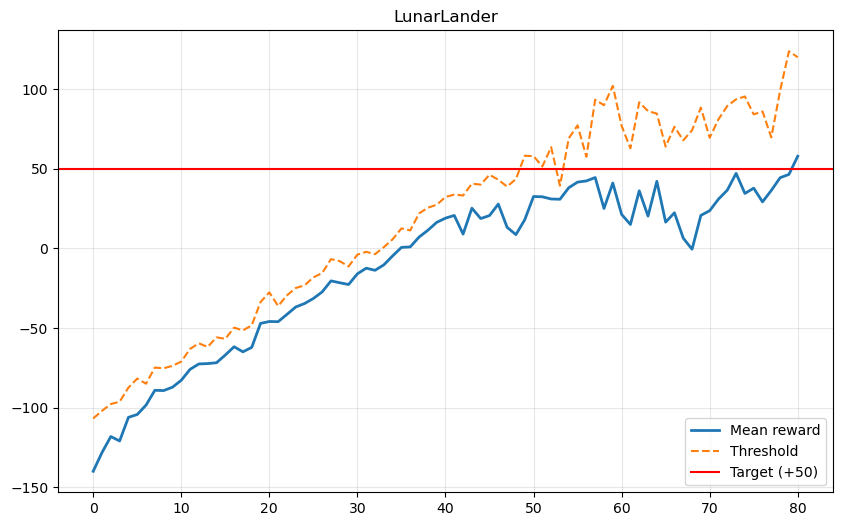

In [25]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

env_lander = gym.make("LunarLander-v3").env
n_actions = env_lander.action_space.n

agent = MLPClassifier(
    hidden_layer_sizes=(128, 128),
    activation='tanh',
    max_iter=1
)

initial_state = env_lander.reset()[0]
agent.partial_fit([initial_state], [0], classes=np.arange(n_actions))

def generate_session_deep(env, agent, t_max=1000):
    states, actions = [], []
    total_reward = 0
    s, _ = env.reset()
    for t in range(t_max):
        probs = agent.predict_proba([s])[0]
        a = np.random.choice(n_actions, p=probs)
        new_s, r, terminated, truncated, _ = env.step(a)
        states.append(s)
        actions.append(a)
        total_reward += r
        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward

def select_elites(states_batch, actions_batch, rewards_batch, percentile=70):
    reward_threshold = np.percentile(rewards_batch, percentile)
    elite_states = []
    elite_actions = []
    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])
    return elite_states, elite_actions, reward_threshold

n_sessions = 150
percentile = 70
n_epochs = 100

mean_rewards_log = []
thresholds_log = []

print("Запуск LunarLander...")

for epoch in range(n_epochs):
    sessions = [generate_session_deep(env_lander, agent) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    
    elite_states, elite_actions, threshold = select_elites(
        states_batch, actions_batch, rewards_batch, percentile
    )
    
    if len(elite_states) > 0:
        agent.partial_fit(elite_states, elite_actions, classes=np.arange(n_actions))
        
    mean_reward = np.mean(rewards_batch)
    mean_rewards_log.append(mean_reward)
    thresholds_log.append(threshold)
    
    print(f"Epoch {epoch}: mean reward = {mean_reward:.3f}, threshold = {threshold:.3f}")
    
    if mean_reward > 50:
        print(f"Задание 2.1 выполнено: порог +50 преодолен на {epoch} шаге!")
        break

# --- Визуализация (как на образце) ---
plt.figure(figsize=(10, 6))
plt.plot(mean_rewards_log, label='Mean reward', color='tab:blue', linewidth=2)
plt.plot(thresholds_log, label='Threshold', color='tab:orange', linestyle='--')
plt.axhline(y=50, color='r', linestyle='-', label='Target (+50)')
plt.title('LunarLander')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

На графике видно, что нейросеть успешно обучается: средняя награда уверенно ползет вверх. В итоге на 80 шаге мы пробили нужный порог в +50 очков, а это значит, что алгоритм научился правильно сажать лунный модуль.

Запуск задачи 2.2...
Эпоха 0: Текущая награда = -168.62
Эпоха 1: Текущая награда = -146.03
Эпоха 2: Текущая награда = -141.30
Эпоха 3: Текущая награда = -135.60
Эпоха 4: Текущая награда = -113.79
Эпоха 5: Текущая награда = -106.21
Эпоха 6: Текущая награда = -95.83
Эпоха 7: Текущая награда = -96.34
Эпоха 8: Текущая награда = -87.12
Эпоха 9: Текущая награда = -77.97
Эпоха 10: Текущая награда = -72.96
Эпоха 11: Текущая награда = -81.42
Эпоха 12: Текущая награда = -68.51
Эпоха 13: Текущая награда = -70.79
Эпоха 14: Текущая награда = -63.30
Эпоха 15: Текущая награда = -69.73
Эпоха 16: Текущая награда = -53.65
Эпоха 17: Текущая награда = -49.46
Эпоха 18: Текущая награда = -46.49
Эпоха 19: Текущая награда = -43.64
Эпоха 20: Текущая награда = -50.94
Эпоха 21: Текущая награда = -39.77
Эпоха 22: Текущая награда = -36.12
Эпоха 23: Текущая награда = -29.55
Эпоха 24: Текущая награда = -29.19
Эпоха 25: Текущая награда = -21.21
Эпоха 26: Текущая награда = -26.39
Эпоха 27: Текущая награда = -22.20
Эпо

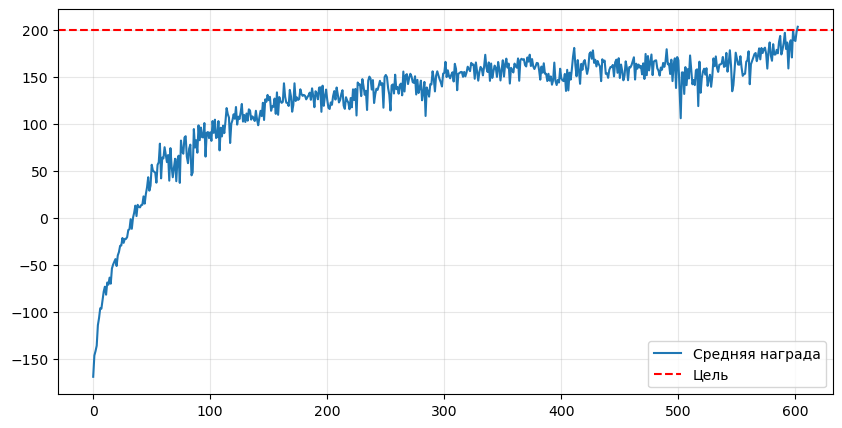

In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from joblib import Parallel, delayed
from collections import deque

def generate_session_worker(env_name, agent, t_max=1000):
    env = gym.make(env_name).env
    states, actions = [], []
    total_reward = 0
    s, _ = env.reset()
    
    for t in range(t_max):
        probs = agent.predict_proba([s])[0]
        a = np.random.choice(len(probs), p=probs)
        new_s, r, terminated, truncated, _ = env.step(a)
        
        states.append(s)
        actions.append(a)
        total_reward += r
        s = new_s
        
        if terminated or truncated:
            break
            
    env.close()
    return states, actions, total_reward

env_name = "LunarLander-v3"
dummy_env = gym.make(env_name)
n_actions = dummy_env.action_space.n

agent = MLPClassifier(
    hidden_layer_sizes=(128, 128),
    activation='relu',
    learning_rate_init=0.002,
    max_iter=1
)

agent.partial_fit([dummy_env.reset()[0]], [0], classes=np.arange(n_actions))

n_sessions_per_epoch = 100 
percentile = 70
n_epochs = 1000
buffer_size = 5

sessions_buffer = deque(maxlen=buffer_size)
mean_rewards_log = []

print("Запуск задачи 2.2...")

for epoch in range(n_epochs):
    new_sessions = Parallel(n_jobs=-1)(
        delayed(generate_session_worker)(env_name, agent) 
        for _ in range(n_sessions_per_epoch)
    )
    
    current_rewards = [s[2] for s in new_sessions]
    current_mean = np.mean(current_rewards)
    mean_rewards_log.append(current_mean)
    
    sessions_buffer.append(new_sessions)
    all_sessions = [s for sublist in sessions_buffer for s in sublist]
    
    states_batch, actions_batch, rewards_batch = zip(*all_sessions)
    
    reward_threshold = np.percentile(rewards_batch, percentile)
    
    elite_states = []
    elite_actions = []
    
    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])
            
    if len(elite_states) > 0:
        agent.partial_fit(elite_states, elite_actions)
        
    print(f"Эпоха {epoch}: Текущая награда = {current_mean:.2f}")
    
    if current_mean > 200:
        print(f"\nЗадача 2.2 выполнена")
        break

plt.figure(figsize=(10, 5))
plt.plot(mean_rewards_log, label='Средняя награда')
plt.axhline(y=200, color='r', linestyle='--', label='Цель')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Чтобы алгоритм работал быстрее и стабильнее, мы добавили распараллеливание через joblib и буфер памяти для хранения прошлых удачных игр. Благодаря этому обучение пошло в разы эффективнее.

### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.